### Imports

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, radians, floor
import random
import json

### Constants

In [2]:
width = 800
height = 600
angles = [0, 15, 30, 60, 90]
lengths = [50, 120, 250]
thicknesses = [1, 2, 4]
no_of_lines = 30
BLACK = (0,0,0)

### 

### Generate 

In [3]:
lines_img = np.full((height, width, 3), 255, dtype=np.uint8)
random.seed()
lines_angles=random.choices(angles, k=no_of_lines)
lines_lengths=random.choices(lengths, k=no_of_lines)
lines_thicknesses=random.choices(thicknesses, k=no_of_lines)
lines = []

for i in range(no_of_lines):
    x1, y1, x2, y2 = 0, 0, 0, 0
    
    while True:
        x1 = random.randint(0, width)
        y1 = random.randint(0, height)
        
        dx = lines_lengths[i]*cos(radians(lines_angles[i]))
        dy = lines_lengths[i]*sin(radians(lines_angles[i]))
        dx, dy = abs(dx), abs(dy)
        
        x2, y2 = floor(x1+dx), floor(y1+dy)
        
        if x2<width and y1<height:
            break
    
    lines.append({
        "start": [x1, y1],
        "end": [x2, y2],
        "angle": lines_angles[i],
        "length": lines_lengths[i],
        "thickness": lines_thicknesses[i]
    })

In [4]:
for line in lines:
    cv.line(lines_img, line["start"], line["end"], BLACK, line["thickness"])

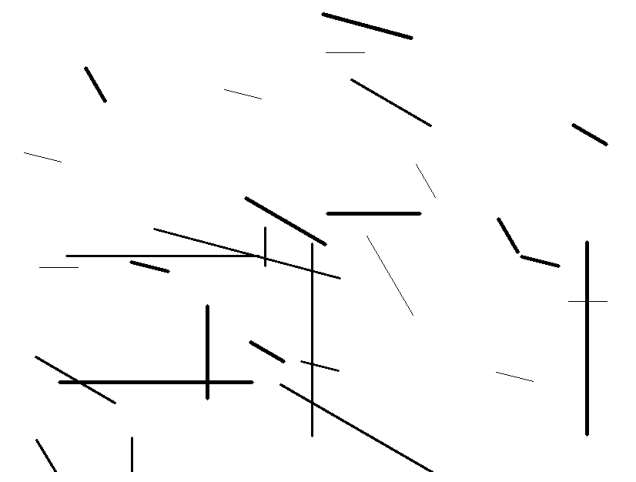

In [5]:
plt.figure(figsize=(8,6))
plt.imshow(lines_img)
plt.axis(False)
plt.show()

In [6]:
cv.imwrite("output/lines_grid.png", lines_img)

with open("output/lines_grid_gt.json", "w") as file:
    json.dump(lines, file, indent=4)

print("Generated lines_grid.png and lines_grid_gt.json")

Generated lines_grid.png and lines_grid_gt.json
